# **Quantum East Model**

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm
import mpmath as mp
import numpy as np
import scipy as scp
import sympy as sp

## **Hamiltonian**
$$ H = - \frac{1}{2} \sum_{i=0}^{N-1} n_i(e^{-s}\sigma_{i+1}^x - 1) $$
$$ H^N = - \frac{1}{2}(e^{-s}\sigma_1^x - 1) - \frac{1}{2} \sum_{i=1}^{N-1} n_i(e^{-s}\sigma_{i+1}^x - 1)$$
$$ H^N_\pm = - \frac{1}{2}(e^{-s}\sigma_1^x - 1) - \frac{1}{2} \sum_{i=1}^{N-1} n_i(e^{-s}\sigma_{i+1}^x - 1) - \frac{1}{2} n_N (\pm e^{-s} - 1)$$

To perform exact diagonalization, we consider the eigenbais of product states of the excitation number operator $n_i = (1-\sigma_i^z)/2$
$$ |\psi\rangle = |n_0\rangle|n_1\rangle\dots|n_N\rangle$$
Such that we can consider subspaces based on the number of flipped spins, $Z \equiv \sum_i \langle n_i \rangle$. In other words $Z$ is (linearly related to) the $z$-magnetization of the chain, thus we consider subspaces labeled by a given magnetization. 
Notice that since the spin at $i=0$ is always up to allow non-trivial dynamics on the $N$-long chain to its east.

## **Indexing of Product States (PS)**
Considering only product states in the computational basis, they can be labeled by an index $\mu\in[0,2^N - 1]$ and the index is given by the assigment of the bit string encoded in the (dynamical) spins of the PS, e.g. for two $N=8$ sample PSs we have: 
$$ |\mu\rangle \equiv |1\rangle |00010011\rangle \to 00010011 \to \mu = 19 $$
$$ |\mu\rangle \equiv |1\rangle |01001111\rangle|+\rangle \to 01001111 \to \mu = 79 $$
where the first example is a PS for $H^N$, while the second example is a PS for $H^N_+$


## **Hamiltonian Matrix Elements**
With the given indexing scheme, we have
$$ \langle\mu|H^N|\nu\rangle = \frac{1}{2} (1 + Z_{\mu} - n'_{N\mu}) \langle\mu|\nu\rangle - \frac{e^{-s}}{2} \left(\langle\mu|\nu^{(1)}\rangle + \sum_{i=1}^{N-1} n'_{i\mu} \langle\mu|\nu^{(i+1)}\rangle\right)$$
$$ \langle\mu|H^N_+|\nu\rangle = \frac{1}{2} (1 + Z_{\mu} - e^{-s}n'_{N\mu}) \langle\mu|\nu\rangle - \frac{e^{-s}}{2} \left(\langle\mu|\nu^{(1)}\rangle + \sum_{i=1}^{N-1} n'_{i\mu} \langle\mu|\nu^{(i+1)}\rangle\right)$$

such that the off diagonal matrix elements only connect states that differ by one bit and satisfy the kinetic constraint. Thus, each row has at most $N+1$ non-zero matrix elements.


### **Functions**

In [4]:
## Working as intended
def make_H_sparse(D, N, s, is_hp=True):
    if is_hp:
        sdiag = s
    else:
        sdiag = 0
    H = scp.sparse.dok_array((D,D))
    for mu in range(D):
        # Input diagonal terms
        H[mu,mu] = (1/2)*(1 + np.bitwise_count(mu) - np.exp(-sdiag)*int((mu & 1) == 1))
        # Construct 1 flip neighbors of i
        nu_set = np.array([mu ^ 2**(N-bit) for bit in range(1, N+1)])
        exp_factor = -np.exp(-s)/2
        # Input off-diagonals
        for nu in nu_set:
            bit_index = int_to_bit_arr(mu ^ nu)[16-N:].nonzero()[0].sum() + 1
            if bit_index == 1:
                H[mu,nu] = exp_factor
                H[nu,mu] = exp_factor
            else:
                kc = int_to_bit_arr(mu)[16-N+bit_index-2]
                H[mu,nu] = exp_factor * kc
                H[nu,mu] = exp_factor * kc
    return H

## Working as intended
def lanczos_mat(M, nmax=100, error=1e-8, v1=None, nmax_strict=False):
    D = M.shape[0]
    # Initialize
    v = np.zeros((D,nmax+1))
    a = np.zeros(nmax+1)
    b = np.zeros(nmax+1)
    if v1 == None:
        rng = np.random.default_rng()
        mu = rng.integers(0, D, endpoint=True)
        v[mu,1] = 1
    else:
        v[:,1] = v1
    a[1] = v[:,1].T @ M @ v[:,1]
    b[1] = 0
    E0 = np.zeros(nmax+1)
    E0[1] = a[1]
    step = 2
    # Perform up to nmax iterations
    while step <= nmax:
        w = M @ v[:,step-1] - a[step-1]*v[:,step-1] - b[step-1]*v[:,step-2]
        b[step] = np.linalg.norm(w)
        v[:,step] = (1/b[step]) * w
        a[step] = v[:,step].T @ M @ v[:,step]
        Mtri_eigenvals = scp.linalg.eigh_tridiagonal(a[1:step+1], b[2:step+1], eigvals_only=True)
        E0[step] = Mtri_eigenvals[0]
        if np.abs(E0[step] - E0[step-1]) < error and not nmax_strict:
            break
        else:
            step += 1
    M_eigenvals, Mtri_eigenvecs = scp.linalg.eigh_tridiagonal(a[1:step+1], b[2:step+1])
    M_eigenvecs = np.matvec(v[:,1:step+1], Mtri_eigenvecs.T).T    # Transposes are for correct np.matvec broadcast
    print(f'Max step: {step}')
    return E0, M_eigenvals, M_eigenvecs

## Working as intended
def int_to_bit_arr(n, base_type='>i2'):
    return np.unpackbits(np.array([n], dtype=base_type).view(np.uint8))

## Working as intended
def avg_n(phi, N, D):
    # Get n_i for all basis states
    ns = np.array([int_to_bit_arr(mu)[16-N:] for mu in range(D)])
    # Multiply by the probabilities of state phi (transposes needed for correct broadcasting of multiplication)
    out_ns = (ns.T * (phi * phi)).T
    return np.sum(out_ns, axis=0)

# Construct matrix of n_i operator 
def make_n(i, N):
    D = 2**N
    diag = np.array([int_to_bit_arr(mu)[16-N:] for mu in range(D)])[:,i-1]
    return scp.sparse.dia_array((diag,0), shape=(D,D))

# Working as intended
def avg_O(mu, ts, Us, N):
    D = 2**N
    # Construct matrices for occupation operators n_i needed
    nonzero_bits = np.nonzero(int_to_bit_arr(mu)[16-N:])[0] + 1
    Z = nonzero_bits.size
    n = {int(i): make_n(i,N) for i in nonzero_bits}
    # Construct column vector representation of initial state
    mu_t = np.array([int(i == mu) for i in range(D)])
    # Establish the time points for evaluation of the correlator O(t)
    #ts = np.array([0] + np.unique(np.logspace(0, int(np.log10(t)), 100, dtype=np.int64)).tolist())
    # Initialize correlator at t = 0 
    O = np.zeros(ts.size)
    O[0] = 1
    for i in range(1, ts.size):
        mu_t = Us[i] @ mu_t
        O[i] = (1/Z)*np.sum([np.conj(mu_t.T) @ n[j] @ mu_t for j in nonzero_bits])
    return scp.integrate.cumulative_trapezoid(O, ts, initial=0)[1:] / ts[1:]


### **Exact Diagonalization with Sparse Matrices for Fig 1**

In [10]:
# Set parameters
N = 10
s = -0.5
D = 2**N

In [8]:
# Construct Hamiltonian H and evolution operator U (time step dt=1)
H = make_H_sparse(D, N, s, is_hp=False)
U = scp.sparse.linalg.expm(-np.csingle('j')*H.tocsc()) #scp.sparse.eye_array(D) - np.csingle('j')*H

In [619]:
# Generate the powers of U needed
ts = np.array([0] + np.unique(np.logspace(0, 10, 100, dtype=np.int64)).tolist())
Us = np.array([scp.sparse.eye_array(D)] + [scp.sparse.linalg.matrix_power(U, ts[i]-ts[i-1]) for i in range(1, ts.size)])
Us.size == ts.size

True

In [ ]:
# Save/Load data
with open('data/H_sparse_10_s-05.npy','wb') as file:
    np.save(file, H)
with open('data/Us_sparse_10_s-05.npy','wb') as file:
    np.save(file, Us)

In [621]:
# Create initial states
initial_states = {3: None,
                  5: None,
                  7: None}

for Z in [3,5,7]:
    initial_states[Z] = np.array([mu for mu in range(D) if np.bitwise_count(mu) == Z])

In [622]:
# Compute the evolution of the correlator
correlators = {3: None,
               5: None,
               7: None}

for Z in [3,5,7]:
    correlators[Z] = np.array([avg_O(mu, ts, Us, N) for mu in initial_states[Z]])

/tmp/ipykernel_2977/3843035191.py:97: ComplexWarning: Casting complex values to real discards the imaginary part
  O[i] = (1/Z)*np.sum([np.conj(mu_t.T) @ n[j] @ mu_t for j in nonzero_bits])


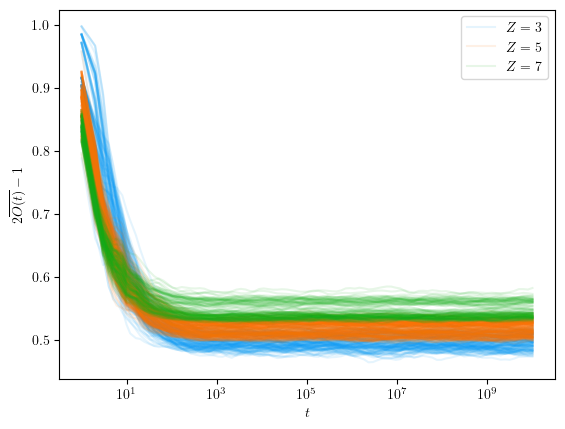

In [624]:
# Plot the correlators vs time
colors = {3: 'xkcd:azure', 
          5: 'xkcd:orange',
          7: 'xkcd:green'}

fig, ax = plt.subplots()
for Z in [3,5,7]:
    ax.plot(ts[1:], correlators[Z][0], c=colors[Z], alpha=0.1, label=r'$Z=$'+f' {Z}')
    for i in range(1,initial_states[Z].size):
        ax.plot(ts[1:], correlators[Z][i], c=colors[Z], alpha=0.1)

ax.legend()
ax.set(xscale='log',
       xlabel=r'$t$',
       ylabel=r'$2\overline{O(t)}-1$')
fig.savefig('Fig1_s-.pdf')

### **Lanczos Method for Fig2**

In [454]:
# Set parameters
N = 15
D = 2**N

In [ ]:
# Obtain the ground states for different s values
s_set = np.array([-0.5, -0.2, 0.1, 0.3, 0.5, 1.0])
s_set = np.sort(np.append(s_set, np.linspace(-0.4, 0.95, 30)))
GSs = np.zeros((D, s_set.size))

for i in range(s_set.size):
    Hp = make_H_sparse(D, N, s_set[i])
    Hp_E0, Hp_eigvals, Hp_eigvecs = lanczos_mat(Hp, nmax=380, nmax_strict=True)
    GSs[:,i] = Hp_eigvecs[:,0]


In [ ]:
# Save/Load data

with open('N15_GSs_380steps.npy', 'wb') as file:
    np.save(file, GSs)
with open('N15_s_set_380steps.npy', 'wb') as file:
    np.save(file, s_set)

In [455]:
# Compute occupation expectation values

s_set_reduced_indices = np.array([i for i in range(s_set.size) if s_set[i] in [-0.5, -0.2, 0.1, 0.3, 0.5, 1.0]])

GSs_avg_ns = np.zeros((N,s_set.size))
for i in range(s_set.size):
    GSs_avg_ns[:,i] = avg_n(GSs[:,i], N, D)

[None, Text(0.5, 0, '$i$'), Text(0, 0.5, '$\\langle n_i \\rangle$')]

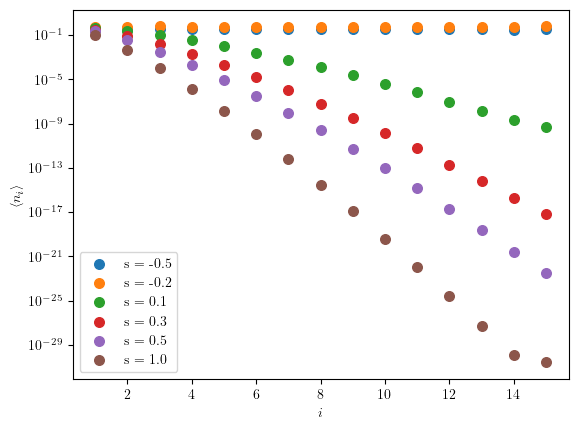

In [ ]:
# Plot average site occupation vs site number

fig, ax = plt.subplots()
for i in s_set_reduced_indices:
    s_label = s_set[i]
    ax.scatter(np.arange(1,N+1), GSs_avg_ns[:,i], s=48, label=f's = {s_label}')
    #ax.plot(np.arange(1,N+1), GSs_avg_ns[:,i])
ax.legend()
ax.set(yscale='log', xlabel=r'$i$', ylabel=r'$\langle n_i \rangle$')
fig.savefig('Fig2.pdf')

In [448]:
# Extract correlation lengths xi

xis = np.zeros(s_set.size)
for i in range(s_set.size):
    result = scp.stats.linregress(np.arange(1,N+1), np.log(GSs_avg_ns[:,i]))
    xis[i] = -1/result.slope

# Curve fit xi vs s

s_positive = np.array([1e-8]+[s_set[i] for i in range(s_set.size) if s_set[i] > 0])
one_over_xis_positive = np.array([1e-8]+ [np.abs(1/xis[i]) for i in range(s_set.size) if s_set[i] > 0])

def one_over_xi_model(s, nu, A):
    return A*s**nu

ptot, pcov = scp.optimize.curve_fit(one_over_xi_model, s_positive, one_over_xis_positive)
nu, A = ptot[0], ptot[1]
xi_fit = np.array(np.zeros(10).tolist() + one_over_xi_model(s_positive, nu, A).tolist())
s_xi_fit = np.array(np.linspace(s_set[0], 0, 10).tolist() + s_positive.tolist())

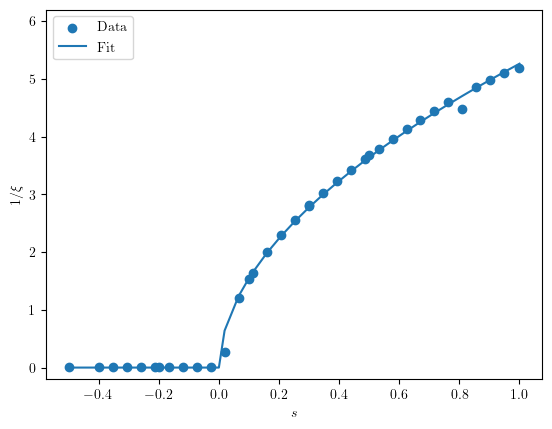

In [449]:
# Plot correlation length vs s dependence

fig, ax = plt.subplots()
ax.scatter(s_set, np.abs(1/xis), label='Data')
ax.plot(s_xi_fit, xi_fit, label='Fit')
ax.legend(loc='upper left')
ax.set(xlabel=r'$s$', 
       ylabel=r'$1/\xi$', 
       ylim=(-0.2,6.2))
fig.savefig('Fig2_inset.pdf')